In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from numpy.polynomial.laguerre import laggauss
#plots for paper
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}' 

_eV_ = 1.602176487e-19  # eV to Joules
_k_B_ = 1.3806504e-23  # Boltzmann constant in J/K
_c_=  2.99792458e8 
_h_P_ = 6.62606896e-34
_G_N_ = 6.67428e-11
_Mpc_over_m_ = 3.085677581282e22

In [5]:
# File paths
file1 = "/rds/general/user/an421/home/CLASS_Original/class_public/output/default_massive_nu04_background.dat"
file2 = "/rds/general/user/an421/home/CLASS_GBH/class/output/default_gbh100_background.dat"

# Read and process the first file
data1 = np.loadtxt(file1, skiprows=4)
z = data1[:, 0]  # Column 1 (z)
rho_ncdm = data1[:, 11]  # Column 12 (rho_ncdm)

# Read and process the second file
data2 = np.loadtxt(file2, skiprows=4)
z1 = data2[:, 0]  # Column 1 (z1)
rho_gbh = 3 * data2[:, 11]/3.044  # 3 * Column 12 (rho_gbh)

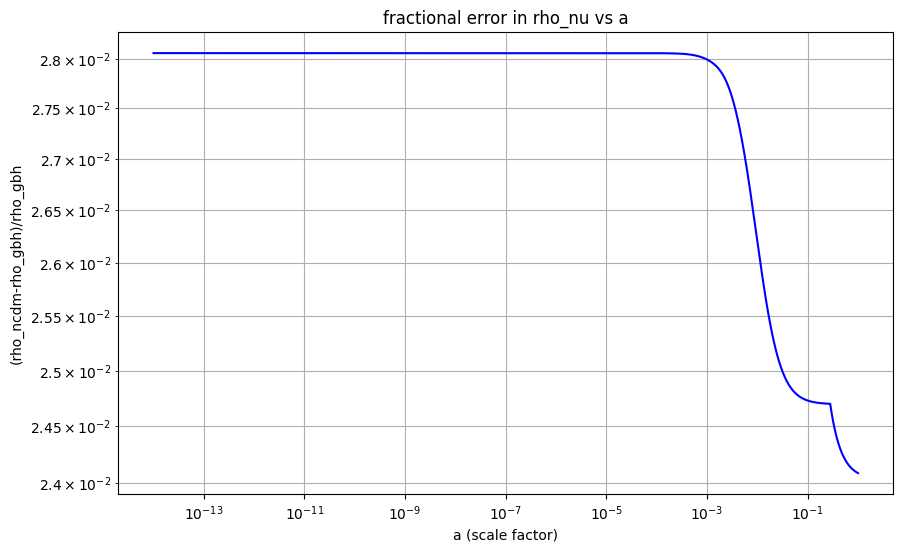

In [10]:
# Plotting
plt.figure(figsize=(10, 6))
plt.loglog(1/(1+z), (rho_ncdm-rho_gbh)/rho_gbh, label="rho_ncdm", color='blue')
#plt.loglog(1/(1+z1), rho_gbh, label="rho_gbh", color='red', linestyle='--')
plt.grid(which="both")
plt.xlabel("a (scale factor)")
plt.ylabel("(rho_ncdm-rho_gbh)/rho_gbh")
plt.title("fractional error in rho_nu vs a")
#plt.legend()
plt.show()

<Figure size 1000x600 with 0 Axes>

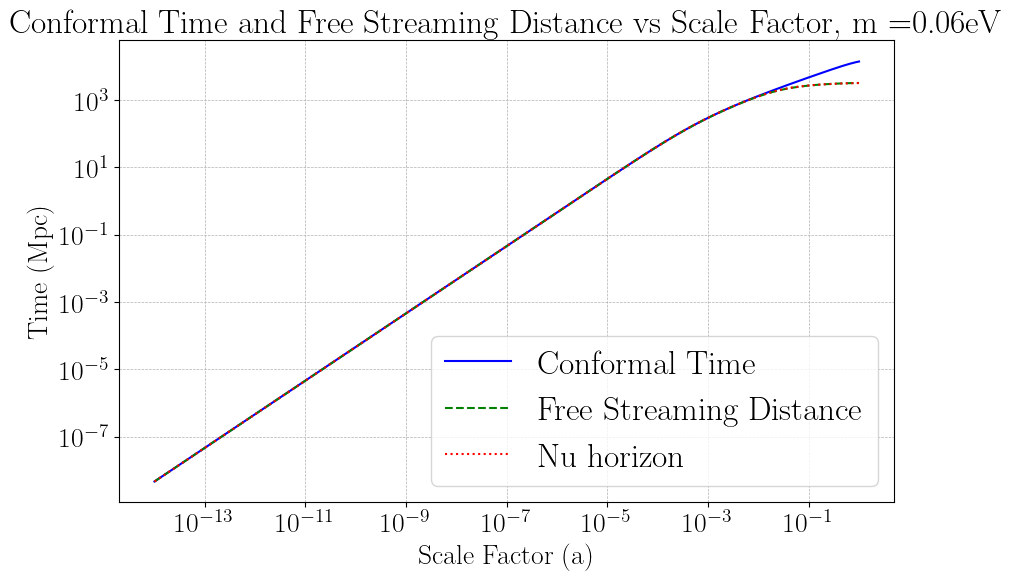

<Figure size 1000x600 with 0 Axes>

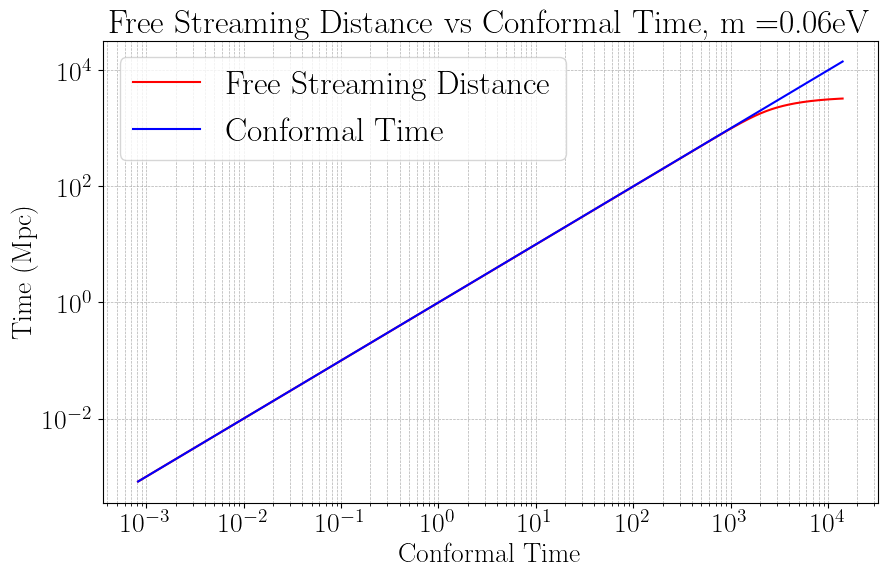

In [29]:
# File path
file_path = "/rds/general/user/an421/home/CLASS_GBH/class/output/default_gbh100_background.dat"

# Read and process the file
data = np.loadtxt(file_path, skiprows=4)
z = data[:, 0]  # Column 1 (z)
Pminus1_gbh_quad = data[:, 13] 
rho_gbh = data[:, 15]*3 # Column 14 (rho_gbh)
lambda_gbh_quad = Pminus1_gbh_quad/rho_gbh
conformal_time = data[:, 2]  # Column 3 (conformal time)
free_streaming_dist = data[:, 42]  # Column 33 (approximate free streaming distance)
horizon = data[:, 43] 
lambda_gbh = data[:, 44] 
Pminus1_gbh = data[:, 45] 
lambda2_gbh = Pminus1_gbh/rho_gbh

a = 1 / (1 + z)  # Compute scale factor a

# Plotting
# Create a single plot with larger font settings
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 20})  # Increase the base font size
plt.figure(figsize=(10, 6))
plt.loglog(a, conformal_time, label="Conformal Time", color='blue')
plt.loglog(a, free_streaming_dist, label="Free Streaming Distance", color='green', linestyle='--')
plt.loglog(a, horizon, label="Nu horizon", color='red', linestyle='dotted')
plt.xlabel("Scale Factor (a)")
plt.ylabel("Time (Mpc)")
plt.title("Conformal Time and Free Streaming Distance vs Scale Factor, m =0.06eV")
plt.legend(fontsize='large')
plt.grid(which="both", linestyle="--", linewidth=0.5)
plt.savefig("conformal_time_vs_a.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Create a single plot with larger font settings
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 20})  # Increase the base font size
plt.figure(figsize=(10, 6))
n=15000
plt.loglog(conformal_time[n:], free_streaming_dist[n:], label="Free Streaming Distance", color='red')
plt.loglog(conformal_time[n:], conformal_time[n:], label="Conformal Time", color='blue')
#plt.loglog(a, free_streaming_dist, label="Free Streaming Distance", color='green', linestyle='--')
plt.xlabel("Conformal Time")
plt.ylabel("Time (Mpc)")
plt.title("Free Streaming Distance vs Conformal Time, m =0.06eV")
plt.legend(fontsize='large')
plt.grid(which="both", linestyle="--", linewidth=0.5)
plt.savefig("conformal_time_vs_a.pdf", dpi=300, bbox_inches='tight')
plt.show()

#

In [7]:
# Function to compute the Gauss–Laguerre integral for rho
m_nu = .03 * _eV_ # mass in Joules
T_cmb = 2.7255 *_k_B_ # Temperature in J
T_nu0 = 0.71611 * T_cmb

def Rho(a, m, T, N=150):
    # Get Gauss–Laguerre nodes and weights
    nodes, weights = laggauss(N)
    a = np.atleast_1d(a)  # Ensure a is a 1D array
    

    def g(y):
        y = np.atleast_1d(y)  # Ensure y is a 1D array
        return y**2 * np.sqrt((y[None,:] * T)**2 + (m * a[:,None])**2) / (1 + np.exp(-y[None,:]))

    # Perform quadrature: I = T * sum_i w_i * g(x_i)
    integrand_values = g(nodes)
    return 8.*np.pi*T**3/(a**4) * np.dot(integrand_values, weights)

#a_values = np.logspace(0.00001, 1, 1000)
Rho_values = Rho(a, m_nu, T_nu0) # in Joules^4 #np.array([P_minus1(a_1, m_nu, T_nu0) for a_1 in a])
Rho_values =(8*np.pi*_G_N_)/(3*_c_**2)* (_Mpc_over_m_**2) * Rho_values /(_h_P_**3*_c_**5) # convert to 1/Mpc^2


In [ ]:
# Function to compute the Gauss–Laguerre integral for P_minus1
m_nu = .03 * _eV_ # mass in Joules
T_cmb = 2.7255 *_k_B_ # Temperature in J
T_nu0 = 0.71611 * T_cmb

def P_minus1(a, m, T, N=100):
    # Get Gauss–Laguerre nodes and weights
    nodes, weights = laggauss(N)
    a = np.atleast_1d(a)  # Ensure a is a 1D array
    

    def g(y):
        y = np.atleast_1d(y)  # Ensure y is a 1D array
        return np.sqrt((y[None,:] * T)**2 + (m * a[:,None])**2)**3 / (1 + np.exp(-y[None,:]))

    # Perform quadrature: I = T * sum_i w_i * g(x_i)
    integrand_values = g(nodes)
    return 8.*np.pi*T/(3 * a**4) * np.dot(integrand_values, weights)

#a_values = np.logspace(0.00001, 1, 1000)
P_minus1_values = P_minus1(a, m_nu, T_nu0) # in Joules^4 #np.array([P_minus1(a_1, m_nu, T_nu0) for a_1 in a])
P_minus1_values =(8*np.pi*_G_N_)/(3*_c_**2)* (_Mpc_over_m_**2) * P_minus1_values /(_h_P_**3*_c_**5) # convert to 1/Mpc^2
lambda_values = P_minus1_values / rho_gbh


<Figure size 1000x600 with 0 Axes>

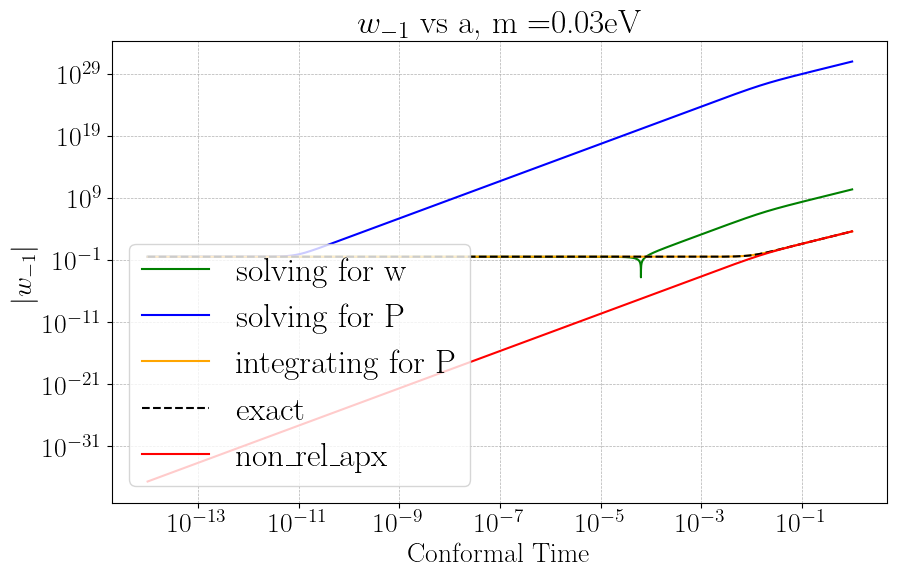

In [23]:
# tests for lambda_gbh
#m_nu = .03 * _eV_ /(_h_P_*_c_) # mass in 1/m
#T_cmb = 2.7255 *_k_B_/(_c_**2) # Temperature in kg
#T_nu0 = 0.71611 * T_cmb
rho = (3*_c_**2/(8*np.pi*_G_N_)) * rho_gbh / (_Mpc_over_m_**2) # density in kg/m^3
apx_lambda = (2*np.pi)**3*np.log(4)/(6*np.pi**2)*(m_nu**3)*T_nu0/rho/a /(_h_P_**3*_c_**5)
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 20})  # Increase the base font size
plt.figure(figsize=(10, 6))
n=0
plt.loglog(a[n:], np.abs(lambda_gbh[n:]), label="solving for w", color='green')
plt.loglog(a[n:], (lambda2_gbh[n:]), label="solving for P", color='blue')
plt.loglog(a[n:], (lambda_gbh_quad[n:]), label="integrating for P", color='orange')
plt.loglog(a[n:], (lambda_values[n:]), label="exact", color='black', linestyle='--')
plt.loglog(a[n:], (apx_lambda[n:]), label="non_rel_apx", color='red')
plt.xlabel("Conformal Time")
plt.ylabel(r"$|w_{-1}|$")
plt.title(r"$w_{-1}$ vs a, m =0.03eV")
plt.legend(fontsize='large', loc='lower left')
plt.grid(which="both", linestyle="--", linewidth=0.5)
plt.savefig("scale factor.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [30]:
lambda_values[0]

1.0471975511976066

In [36]:
x0=0.06/1.3806504e-23*1.602176487e-19/(pow(4./11.,1./3.)*2.7255)
print(x0)
rho0=18.280884768105416*x0/100 * 3.044 * 15./pow(3.14159265,2)*pow(4./11.,4./3.)*(5.37815e-05) * pow(.67810*1.e5/2.99792458e8,2)
print(rho0,rho_gbh[-1]*3.044,rho_ncdm[-1])

357.9117252007074
2.16177937287559e-10 2.1617797572335996e-10 7.167707131021e-11


In [3]:
# File paths
file1 = "/rds/general/user/an421/home/CLASS_Original/class_public/output/default_massive_nu09_perturbations_k0_s.dat"
file2 = "/rds/general/user/an421/home/CLASS_GBH/class/output/default_gbh100_perturbations_k0_s.dat"

# Read and process the first file
data1 = np.loadtxt(file1, skiprows=2)
tau = data1[:, 0]  # Column 1 (z)
delta_ncdm = data1[:, 17]  # Column 13 (rho_ncdm)
delta_ur = data1[:, 12]  # Column 13 (rho_ncdm)
phi = data1[:, 11]  # Column 12 (phi)

# Read and process the second file
data2 = np.loadtxt(file2, skiprows=2)
tau1 = data2[:, 0]  # Column 1 (z1)
delta_gbh = data2[:, 17]  # 3 * Column 18 (rho_gbh)
delta_ur1 = data1[:, 12]  # Column 13 (rho_ncdm)
phi1 = data2[:, 11]  # Column 12 (phi)

print(tau[0],tau1[0])

78.85948804987 78.86116530903


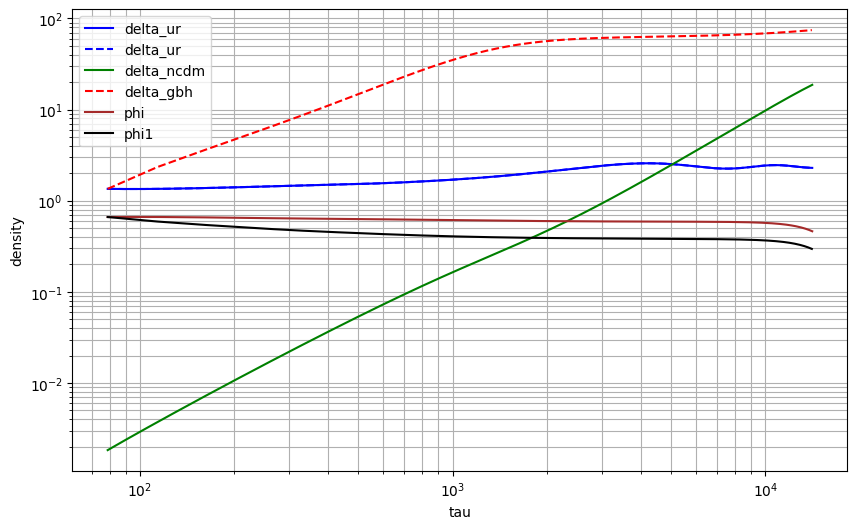

In [4]:
# Plotting
plt.figure(figsize=(10, 6))
plt.loglog(tau, np.abs(delta_ur), label="delta_ur", color='blue')
plt.loglog(tau, np.abs(delta_ur1), label="delta_ur", color='blue',linestyle='--')
plt.loglog(tau, np.abs(delta_ncdm), label="delta_ncdm", color='green')
plt.loglog(tau1, np.abs(delta_gbh), label="delta_gbh", color='red', linestyle='--')
plt.loglog(tau, np.abs(phi), label="phi", color='brown', linestyle='-')
plt.loglog(tau1, np.abs(phi1), label="phi1", color='black', linestyle='-')
plt.grid(which="both")
plt.xlabel("tau")
plt.ylabel("density")
#plt.title("fractional error in rho_nu vs a")
plt.legend()
plt.show()

/rds/general/user/an421/home/anaconda3/envs/myenv/lib/python3.7/site-packages/ipykernel_launcher.py:32: UserWarning: Data has no positive values, and therefore cannot be log-scaled.


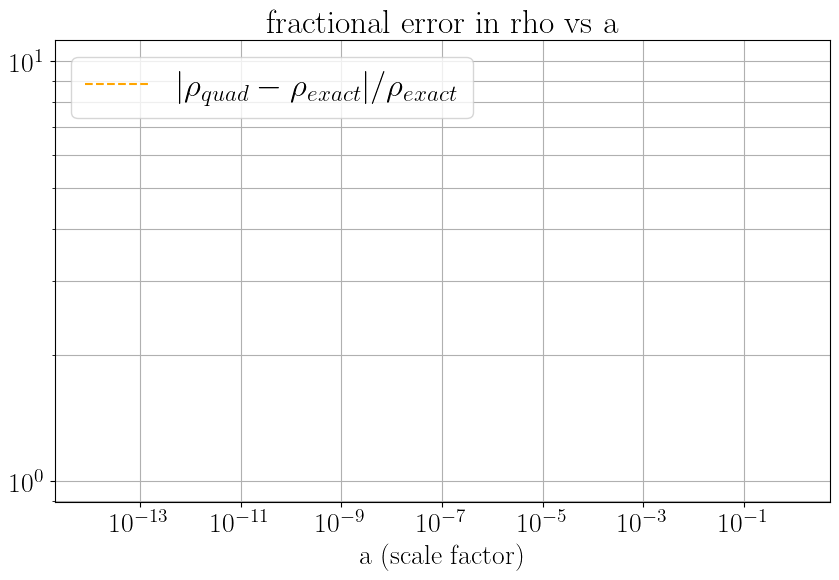

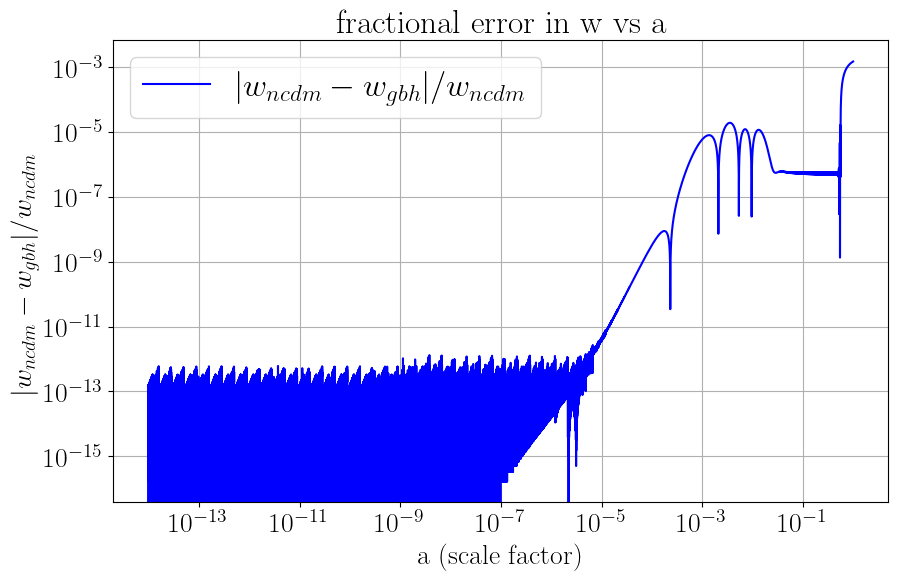

1.0131982214534583


In [17]:
#ncdm and gbh together



file = "/rds/general/user/an421/home/CLASS_GBH/class/output/default_gbh100_background.dat"

# Read and process the first file
data1 = np.loadtxt(file, skiprows=4)
z = data1[:, 0]  # Column 1 (z)
rho_ncdm = data1[:, 11]  # Column 12 (rho_ncdm)
p_ncdm = data1[:, 12]
w_ncdm = p_ncdm/rho_ncdm
rho_ur = data1[:, 47]  # Column 46 (rho_ncdm)
rho_gbh_quad = data1[:, 14]
rho_gbh = 3*data1[:, 15]  # 3 * Column 14 (rho_gbh)
p_gbh = data1[:, 16]
w_gbh=p_gbh/rho_gbh

# Plotting
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 20})  # Increase the base font size
#plt.loglog(1/(1+z)[:], np.abs(rho_gbh[:]-rho_ur[:]/1.0176)/rho_ur, label=r"$|\rho_{gbh}-\rho_{ur}|/\rho_{ur}$", color='red')
#plt.loglog(1/(1+z)[:], np.abs(rho_ncdm[:]-rho_gbh[:])/rho_ncdm, label=r"$|\rho_{ncdm}-\rho_{gbh}|/\rho_{ncdm}$", color='green')
#plt.loglog(1/(1+z)[:], np.abs(Rho_values[:]-rho_gbh[:])/Rho_values, label=r"$|\rho_{exact}-\rho_{gbh}|/\rho_{exact}$", color='black', linestyle='dotted')
#plt.loglog(1/(1+z)[:], np.abs(Rho_values[:]-rho_ncdm[:])/Rho_values, label=r"$|\rho_{exact}-\rho_{ncdm}|/\rho_{exact}$", color='blue', linestyle='--')
plt.loglog(1/(1+z)[:], np.abs(rho_gbh_quad[:]-rho_ncdm[:])/rho_ncdm, label=r"$|\rho_{quad}-\rho_{exact}|/\rho_{exact}$", color='orange', linestyle='--')
plt.grid(which="both")
plt.xlabel("a (scale factor)")
#plt.ylabel(r"$(\rho_{gbh}-\rho_{ur})/\rho_{gbh}$")
plt.title("fractional error in rho vs a")
plt.legend(fontsize='large', loc = 'upper left')
plt.savefig("error_in_rho.pdf", dpi=300, bbox_inches='tight')
plt.show()
# Plotting
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 20})  # Increase the base font size
plt.loglog(1/(1+z)[:], np.abs(w_ncdm[:]-w_gbh)/w_ncdm, label=r"$|w_{ncdm}-w_{gbh}|/w_{ncdm}$", color='blue')
#plt.loglog(1/(1+z)[:], w_gbh[:], label="rho_gbh", color='red')
plt.grid(which="both")
plt.xlabel("a (scale factor)")
plt.ylabel(r"$|w_{ncdm}-w_{gbh}|/w_{ncdm}$")
plt.title("fractional error in w vs a")
plt.legend(fontsize='large')
plt.savefig("error_in_w.pdf", dpi=300, bbox_inches='tight')
plt.show()
print(rho_ncdm[0]/(rho_ur[0]/1.0176))

In [18]:
np.max(np.abs(rho_gbh_quad[:]-rho_ncdm[:]))

0.0

In [6]:


file_path = "/rds/general/user/an421/home/CLASS_GBH/class/output/default_gbh100_background.dat"
# Read and process the file
data = np.loadtxt(file_path, skiprows=4)
z = data[:, 0]  # Column 1 (z)
conformal_time = data[:, 2]  # Column 3 (conformal time)
free_streaming_dist = data[:, 42]  # Column 43 (free streaming distance)

# File paths
file2 = "/rds/general/user/an421/home/CLASS_GBH/class/output/default_gbh100_perturbations_k3_s.dat"
k=.1

# Compute kT values
kT_values = k * free_streaming_dist

# Find index where kT crosses 15
idx = np.searchsorted(kT_values, 15)

# Perform linear interpolation for T
Tau_low, Tau_high = conformal_time[idx - 1], conformal_time[idx]
kT_low, kT_high = kT_values[idx - 1], kT_values[idx]

Tau_interp = Tau_low + (15 - kT_low) * (Tau_high - Tau_low) / (kT_high - kT_low)
#T_interp=conformal_time[idx - 1]


# Read and process the second file
data = np.loadtxt(file2, skiprows=2)
tau = data[:, 0]  # Column 1 (z1)
delta_ncdm = data[:, 17]  # Column 18
theta_ncdm = data[:, 18]  # Column 19
sigma_ncdm = data[:, 19]
cs2_ncdm = data[:, 20]
delta_gbh = data[:, 21]  # 
delta1_gbh = data[:, 22]
cs2_gbh = delta1_gbh/delta_gbh
theta_gbh = data[:, 23]  #  
sigma_gbh = data[:, 25]
delta_ur = data[:, 12]  # Column 13 
phi = data[:, 11]  # Column 12 (phi)



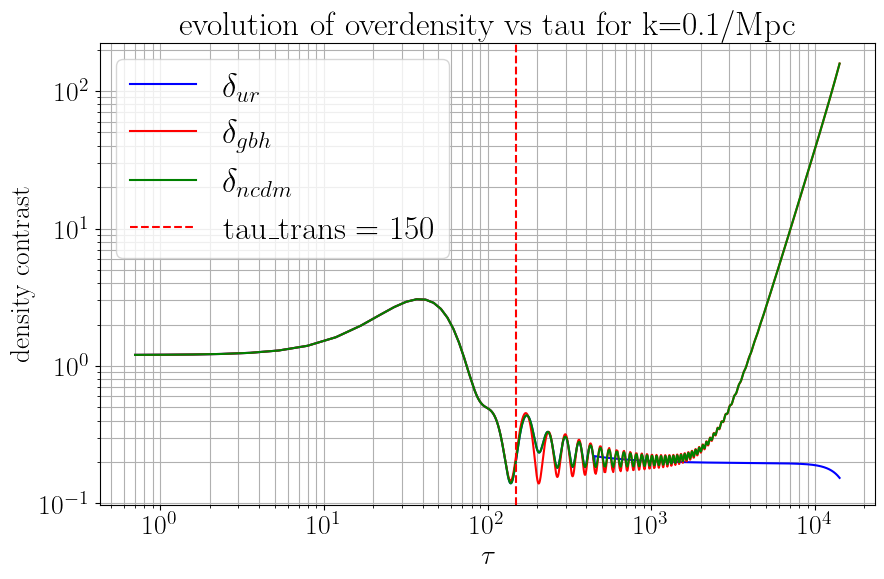

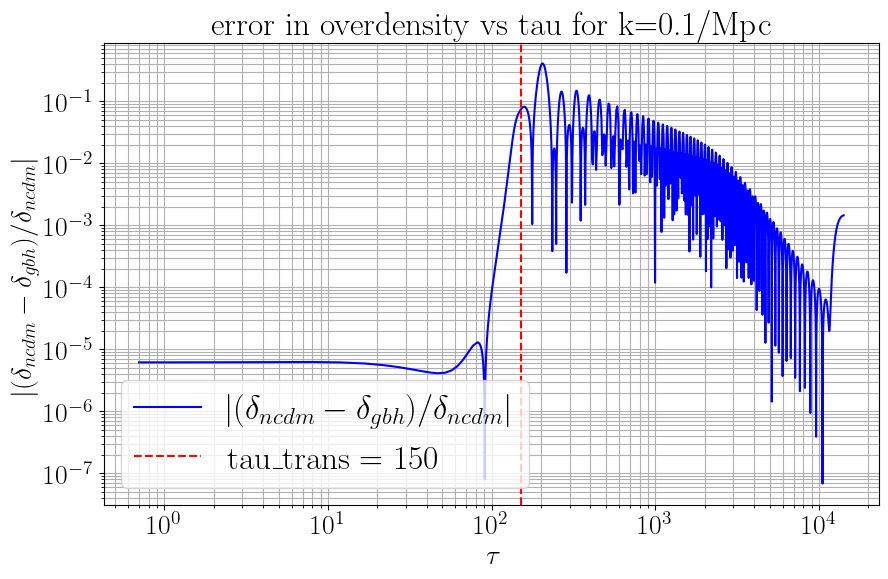

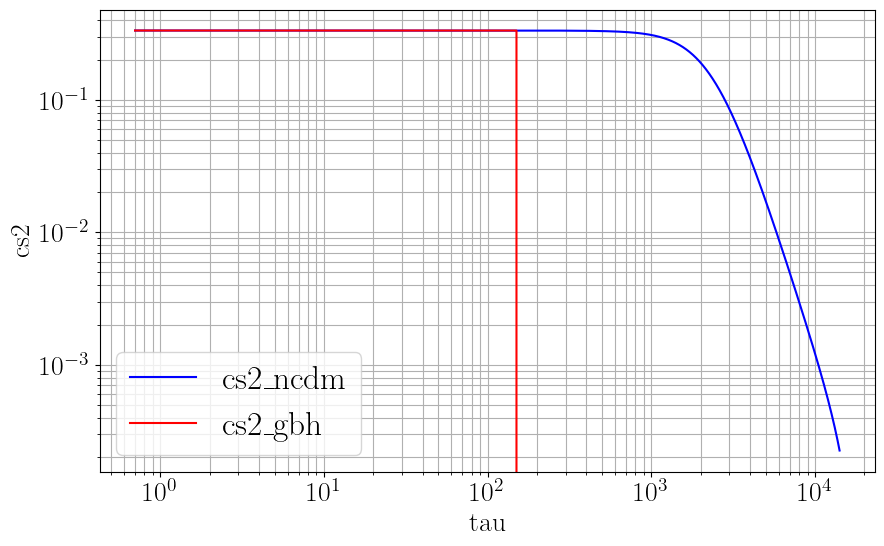

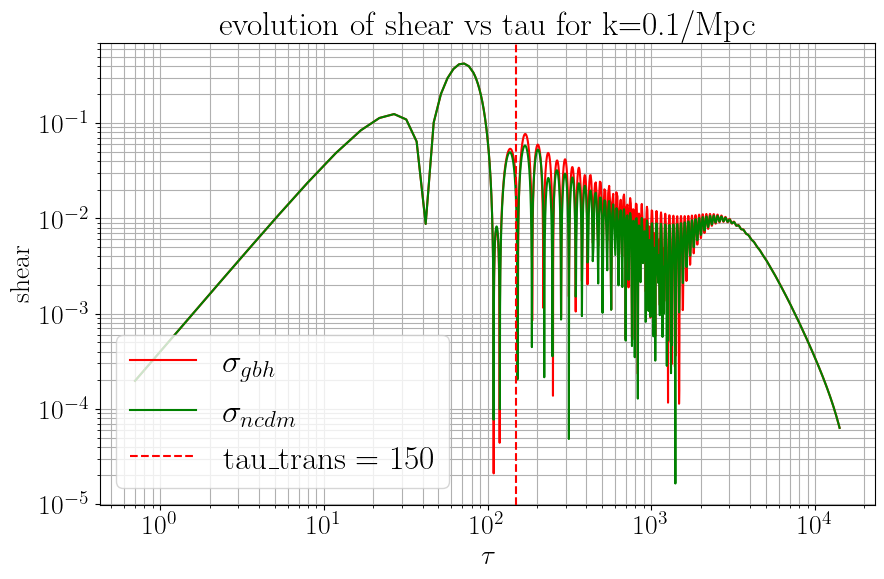

In [7]:
# Plotting
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 20})  # Increase the base font size
plt.loglog(tau, np.abs(delta_ur), label=r"$\delta_{ur}$", color='blue')
plt.loglog(tau, np.abs(delta_gbh), label=r"$\delta_{gbh}$", color='red')
plt.loglog(tau, np.abs(delta_ncdm), label=r"$\delta_{ncdm}$", color='green')
# Add vertical line at T_interp
plt.axvline(x=Tau_interp, color='red', linestyle='--', label=f"tau_trans = {Tau_interp:.0f}")
#plt.loglog(tau, np.abs(theta_gbh), label="theta_gbh", color='red', linestyle='--')
#plt.loglog(tau, np.abs(theta_ncdm), label="theta_ncdm", color='green', linestyle='--')
#plt.loglog(tau, np.abs(sigma_gbh), label="sigma_gbh", color='black')
#plt.loglog(tau, np.abs(sigma_ncdm), label="sigma_ncdm", color='grey')
#plt.loglog(tau, np.abs(phi), label="phi", color='brown', linestyle='--')
plt.grid(which="both")
plt.xlabel(r"$\tau$")
plt.ylabel("density contrast")
plt.title("evolution of overdensity vs tau for k=0.1/Mpc")
plt.legend(fontsize='large')
plt.savefig("delta_vs_tau_k=1e-1.pdf", dpi=300, bbox_inches='tight')
plt.show()
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 20})  # Increase the base font size
plt.loglog(tau, np.abs((delta_ncdm-delta_gbh)/delta_ncdm), label=r"$|(\delta_{ncdm}-\delta_{gbh})/\delta_{ncdm}|$", color='blue')
#plt.loglog(tau, np.abs(delta_gbh), label=r"$\delta_{gbh}$", color='red')
#plt.loglog(tau, np.abs(delta_ncdm), label=r"$\delta_{ncdm}$", color='green')
# Add vertical line at T_interp
plt.axvline(x=Tau_interp, color='red', linestyle='--', label=f"tau_trans = {Tau_interp:.0f}")
plt.grid(which="both")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$|(\delta_{ncdm}-\delta_{gbh})/\delta_{ncdm}|$")
plt.title("error in overdensity vs tau for k=0.1/Mpc")
plt.legend(fontsize='large')
plt.savefig("error_delta_vs_tau_k=1e-1.pdf", dpi=300, bbox_inches='tight')
plt.show()
# Plotting
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 20})  # Increase the base font size
plt.loglog(tau, np.abs(cs2_ncdm), label="cs2_ncdm", color='blue')
plt.loglog(tau, np.abs(cs2_gbh), label="cs2_gbh", color='red')
plt.grid(which="both")
plt.xlabel("tau")
plt.ylabel("cs2")
#plt.title("fractional error in rho_nu vs a")
plt.legend(fontsize='large')
plt.show()


plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 20})  # Increase the base font size
#plt.loglog(tau, np.abs(delta_ur), label=r"$\delta_{ur}$", color='blue')
plt.loglog(tau, np.abs(sigma_gbh), label=r"$\sigma_{gbh}$", color='red')
plt.loglog(tau, np.abs(sigma_ncdm), label=r"$\sigma_{ncdm}$", color='green')
# Add vertical line at T_interp
plt.axvline(x=Tau_interp, color='red', linestyle='--', label=f"tau_trans = {Tau_interp:.0f}")
#plt.loglog(tau, np.abs(theta_gbh), label="theta_gbh", color='red', linestyle='--')
#plt.loglog(tau, np.abs(theta_ncdm), label="theta_ncdm", color='green', linestyle='--')
#plt.loglog(tau, np.abs(sigma_gbh), label="sigma_gbh", color='black')
#plt.loglog(tau, np.abs(sigma_ncdm), label="sigma_ncdm", color='grey')
#plt.loglog(tau, np.abs(phi), label="phi", color='brown', linestyle='--')
plt.grid(which="both")
plt.xlabel(r"$\tau$")
plt.ylabel("shear")
plt.title("evolution of shear vs tau for k=0.1/Mpc")
plt.legend(fontsize='large')
plt.savefig("sigma_vs_tau_k=1e-1.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
#transfer function


file = "/rds/general/user/an421/home/CLASS_GBH/class/output/default_gbh100_tk.dat"

# Read and process the first file
data1 = np.loadtxt(file, skiprows=9)
k = data1[:, 0]  # Column 1 (z)
d_ur = data1[:, 4]  
d_ncdm = data1[:, 5]  
d_gbh = data1[:, 6]  

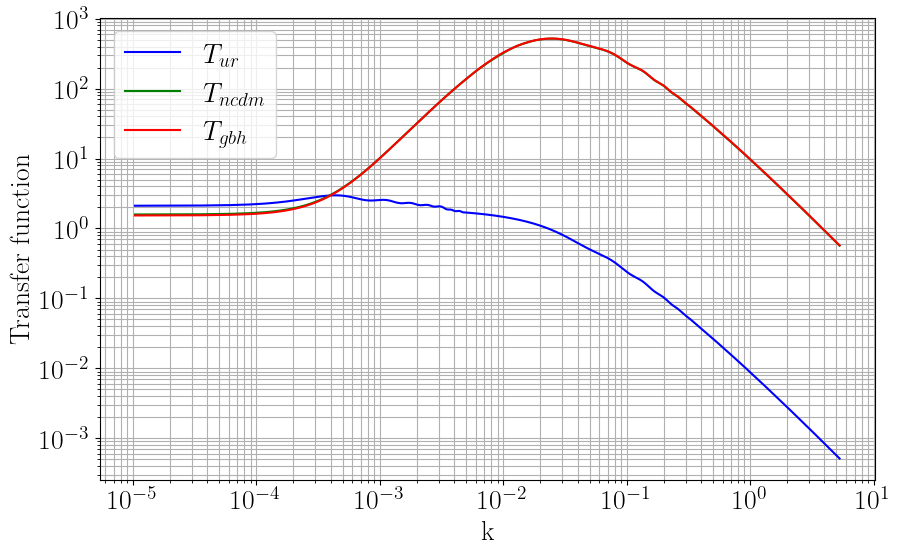

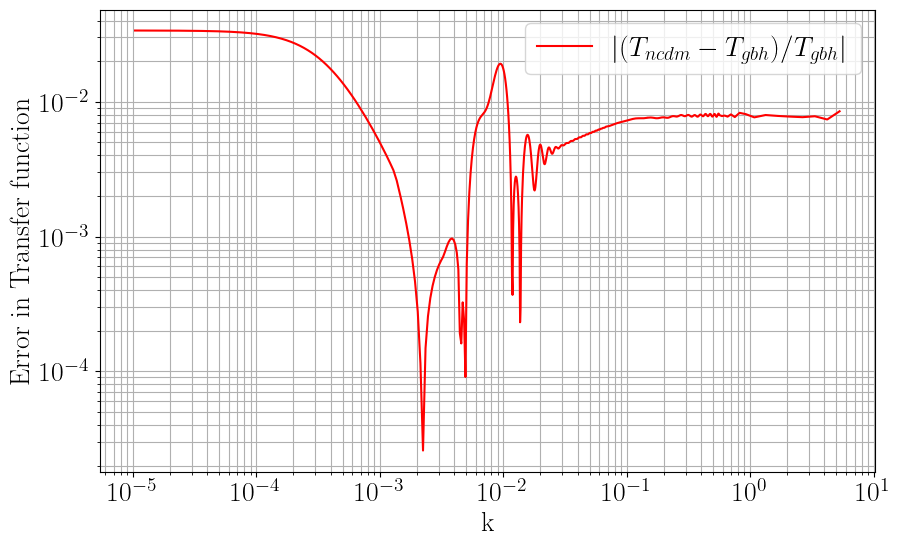

In [50]:

# Plotting
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 20})  # Increase the base font size

plt.loglog(k, np.abs(d_ur), label=r"$T_{ur}$", color='blue')
plt.loglog(k, np.abs(d_ncdm), label=r"$T_{ncdm}$", color='green')
plt.loglog(k, np.abs(d_gbh), label=r"$T_{gbh}$", color='red')
plt.grid(which="both")
plt.xlabel("k")
plt.ylabel("Transfer function")
#plt.title("fractional error in rho_nu vs a")
plt.legend()
plt.savefig("transfer_func.pdf", dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 20})  # Increase the base font size


#plt.loglog(k, np.abs(d_ncdm), label=r"$T_{ncdm}$", color='green')
plt.loglog(k, np.abs((d_ncdm-d_gbh)/d_gbh), label=r"$|(T_{ncdm}-T_{gbh})/T_{gbh}|$", color='red')
plt.grid(which="both")
plt.xlabel("k")
plt.ylabel("Error in Transfer function")
#plt.title("fractional error in rho_nu vs a")
plt.legend()
plt.savefig("error_transfer_func.pdf", dpi=300, bbox_inches='tight')
plt.show()

Comparison beween CLASS and Caio's FA

In [11]:


file_path = "/rds/general/user/an421/home/CLASS_GBH/class/output/default_gbh00_background.dat"
# Read and process the file
data = np.loadtxt(file_path, skiprows=4)
z = data[:, 0]  # Column 1 (z)
conformal_time = data[:, 2]  # Column 3 (conformal time)
free_streaming_dist = data[:, 46]  # Column 43 (free streaming distance)

file_path = "/rds/general/user/an421/home/CLASS_GBH/class/output/default_gbh100_background.dat"
# Read and process the file
data = np.loadtxt(file_path, skiprows=4)
z_C = data[:, 0]  # Column 1 (z)

# File paths
file2Caio = "/rds/general/user/an421/home/CLASS_GBH/class/output/default_gbh00_perturbations_k3_s.dat"
file3CLASS = "/rds/general/user/an421/home/CLASS_GBH/class/output/default_gbh100_perturbations_k3_s.dat"
k=.1

# Compute kT values
kT_values = k * free_streaming_dist

# Find index where kT crosses 15
idx = np.searchsorted(kT_values, 15)

# Perform linear interpolation for T
#Tau_low, Tau_high = conformal_time[idx - 1], conformal_time[idx]
#kT_low, kT_high = kT_values[idx - 1], kT_values[idx]

#Tau_interp = Tau_low + (15 - kT_low) * (Tau_high - Tau_low) / (kT_high - kT_low)
#T_interp=conformal_time[idx - 1]


# Read and process the second file
data = np.loadtxt(file2Caio, skiprows=2)
tau = data[:, 0]  # Column 1 (z1)
delta_ncdm = data[:, 17]  # Column 18
theta_ncdm = data[:, 18]  # Column 19
sigma_ncdm = data[:, 19]
cs2_ncdm = data[:, 20]
delta_gbh = data[:, 21]  # 
delta1_gbh = data[:, 22]
cs2_gbh = delta1_gbh/delta_gbh
theta_gbh = data[:, 23]  #  
sigma_gbh = data[:, 25]
delta_ur = data[:, 12]  # Column 13 
phi = data[:, 11]  # Column 12 (phi)

data = np.loadtxt(file3CLASS, skiprows=2)
tau_C = data[:, 0]  # Column 1 (z1)
delta_ncdm_C = data[:, 17]  # Column 18
theta_ncdm_C = data[:, 18]  # Column 19
sigma_ncdm_C = data[:, 19]
cs2_ncdm_C = data[:, 20]
delta_gbh_C = data[:, 21]  # 
delta1_gbh_C = data[:, 22]
cs2_gbh_C = delta1_gbh_C/delta_gbh_C
theta_gbh_C = data[:, 23]  #  
sigma_gbh_C = data[:, 25]
delta_ur_C = data[:, 12]  # Column 13 
phi_C = data[:, 11]  # Column 12 (phi)


z_tau   = np.interp(tau, conformal_time, z)
z_tau_C = np.interp(tau_C, conformal_time, z_C)
a_tau   = 1.0/(1.0 + z_tau)
a_tau_C   = 1.0/(1.0 + z_tau_C)
a_trans= 1/(1+z[idx])
a_trans

0.00041282443399903946

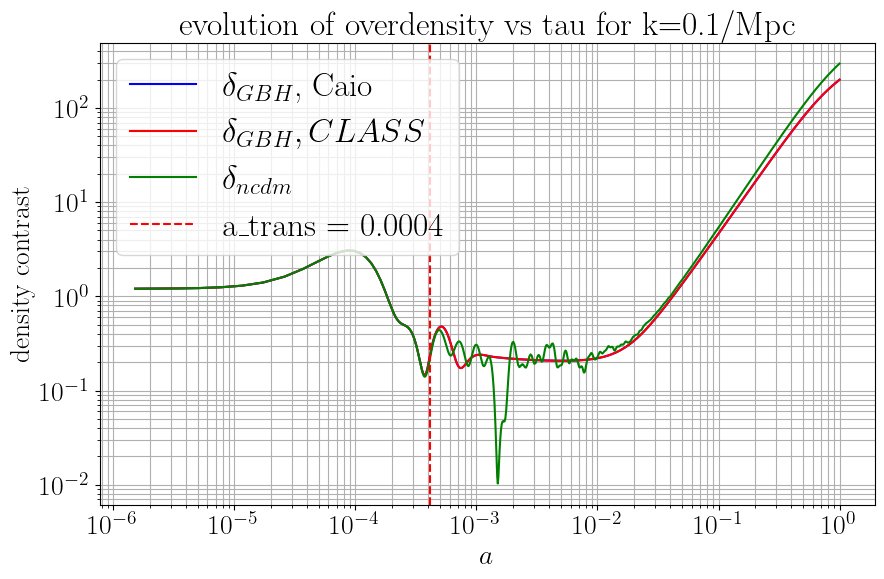

In [12]:
# Plotting
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 20})  # Increase the base font size
plt.loglog(a_tau, np.abs(delta_gbh), label=r"$\delta_{GBH}$, Caio", color='blue')
plt.loglog(a_tau_C, np.abs(delta_gbh_C), label=r"$\delta_{GBH}, CLASS$", color='red')
plt.loglog(a_tau_C, np.abs(delta_ncdm_C), label=r"$\delta_{ncdm}$", color='green')

# Add vertical line at T_interp
plt.axvline(x=a_trans, color='red', linestyle='--', label=f"a_trans = {a_trans:.4f}")
#plt.loglog(tau, np.abs(theta_gbh), label="theta_gbh", color='red', linestyle='--')
#plt.loglog(tau, np.abs(theta_ncdm), label="theta_ncdm", color='green', linestyle='--')
#plt.loglog(tau, np.abs(sigma_gbh), label="sigma_gbh", color='black')
#plt.loglog(tau, np.abs(sigma_ncdm), label="sigma_ncdm", color='grey')
#plt.loglog(tau, np.abs(phi), label="phi", color='brown', linestyle='--')
plt.grid(which="both")
#plt.xscale('log')
plt.xlabel(r"$a$")
plt.ylabel("density contrast")
plt.title("evolution of overdensity vs tau for k=0.1/Mpc")
plt.legend(fontsize='large')
#plt.savefig("delta_vs_tau_k=1e-1.pdf", dpi=300, bbox_inches='tight')
plt.show()


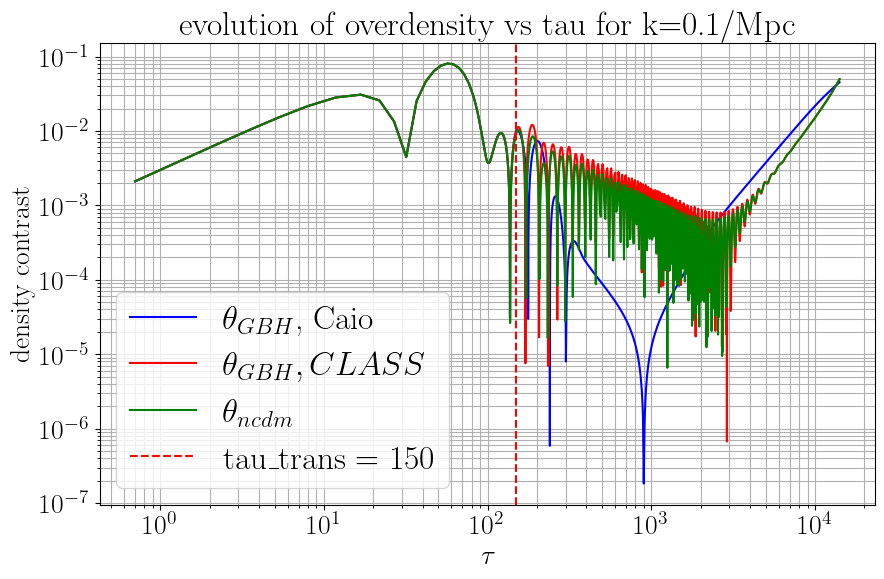

In [14]:
# Plotting
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 20})  # Increase the base font size
plt.loglog(tau, np.abs(theta_gbh), label=r"$\theta_{GBH}$, Caio", color='blue')
plt.loglog(tau, np.abs(theta_gbh_C), label=r"$\theta_{GBH}, CLASS$", color='red')
plt.loglog(tau, np.abs(theta_ncdm_C), label=r"$\theta_{ncdm}$", color='green')

# Add vertical line at T_interp
plt.axvline(x=Tau_interp, color='red', linestyle='--', label=f"tau_trans = {Tau_interp:.0f}")
#plt.loglog(tau, np.abs(theta_gbh), label="theta_gbh", color='red', linestyle='--')
#plt.loglog(tau, np.abs(theta_ncdm), label="theta_ncdm", color='green', linestyle='--')
#plt.loglog(tau, np.abs(sigma_gbh), label="sigma_gbh", color='black')
#plt.loglog(tau, np.abs(sigma_ncdm), label="sigma_ncdm", color='grey')
#plt.loglog(tau, np.abs(phi), label="phi", color='brown', linestyle='--')
plt.grid(which="both")
plt.xlabel(r"$\tau$")
plt.ylabel("density contrast")
plt.title("evolution of overdensity vs tau for k=0.1/Mpc")
plt.legend(fontsize='large')
#plt.savefig("delta_vs_tau_k=1e-1.pdf", dpi=300, bbox_inches='tight')
plt.show()


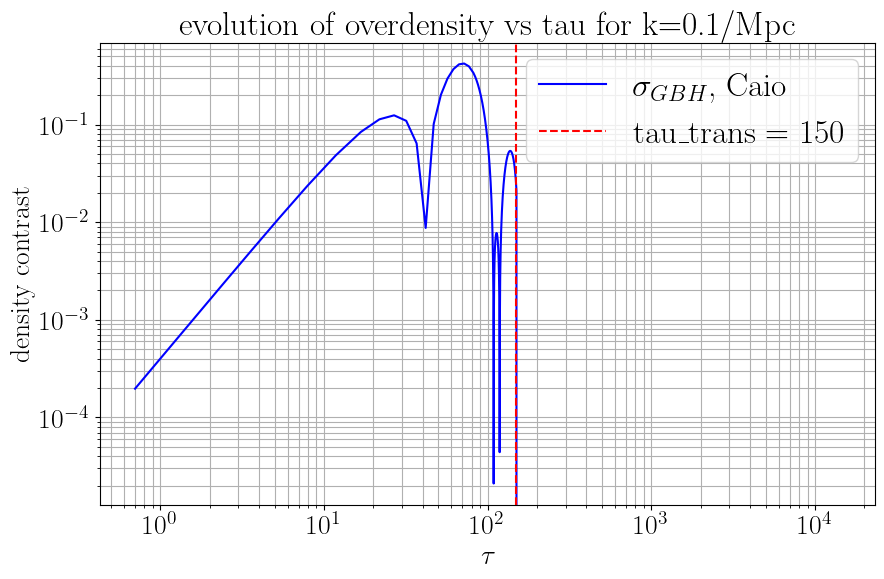

In [19]:
# Plotting
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 20})  # Increase the base font size
plt.loglog(tau, np.abs(sigma_gbh), label=r"$\sigma_{GBH}$, Caio", color='blue')
#plt.loglog(tau, np.abs(sigma_gbh_C), label=r"$\sigma_{GBH}, CLASS$", color='red')
#plt.loglog(tau, np.abs(sigma_ncdm_C), label=r"$\sigma_{ncdm}$", color='green')

# Add vertical line at T_interp
plt.axvline(x=Tau_interp, color='red', linestyle='--', label=f"tau_trans = {Tau_interp:.0f}")
#plt.loglog(tau, np.abs(theta_gbh), label="theta_gbh", color='red', linestyle='--')
#plt.loglog(tau, np.abs(theta_ncdm), label="theta_ncdm", color='green', linestyle='--')
#plt.loglog(tau, np.abs(sigma_gbh), label="sigma_gbh", color='black')
#plt.loglog(tau, np.abs(sigma_ncdm), label="sigma_ncdm", color='grey')
#plt.loglog(tau, np.abs(phi), label="phi", color='brown', linestyle='--')
plt.grid(which="both")
plt.xlabel(r"$\tau$")
plt.ylabel("density contrast")
plt.title("evolution of overdensity vs tau for k=0.1/Mpc")
plt.legend(fontsize='large')
#plt.savefig("delta_vs_tau_k=1e-1.pdf", dpi=300, bbox_inches='tight')
plt.show()
